In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import warnings 
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("loan_sanction_test.csv")

In [6]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [9]:
df.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

- The given loan dataset contains 367 records and 12 columns,
representing applicant and loan-related details that can be used
to predict loan approval decisions. There are missing values which makes the data messy and unreliable for proper analysis,
and the dataset includes both categorical (7) and numerical (5)
variables. The categorical features describe demographic and
employment details, while the numerical features represent
income, loan, and credit information.

  # Description
- ApplicantIncome: The main applicant’s monthly income (numeric).
- CoapplicantIncome: Income of the co-applicant, if any
- LoanAmount: The total amount of loan requested.
- Loan_Amount_Term: The duration (in months) for which the loan is taken.
- Credit_History: Indicates credit reliability (1 for good record, 0 for poor/no record).
- Property_Area: Type of area where the property is located (Urban, SemiUrban, Rural).                                                                

- Data Cleaning and Pre-Processing 

In [16]:
# Handling null values
df.Gender.fillna("Unknown",inplace=True)

In [17]:
df.Dependents.fillna("0",inplace=True)

In [18]:
df.Self_Employed.fillna("No",inplace=True)

In [23]:
df["LoanAmount"].fillna(df["LoanAmount"].mean(),inplace=True)

In [24]:
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mean(),inplace=True)

In [25]:
df.Credit_History.fillna("1.0",inplace=True)

In [33]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [46]:

df.Credit_history=df.Credit_History.astype("float")
df.Credit_History.dtype

dtype('O')

<Axes: >

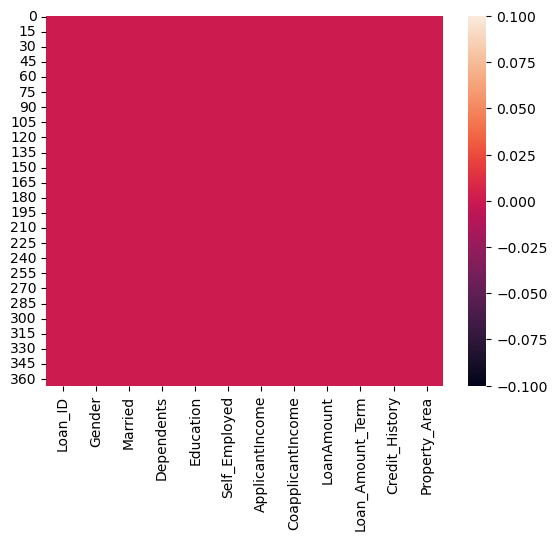

In [27]:
sns.heatmap(df.isnull())

- Univariate Analysis -- Distributions --> histograms, pi charts, kdeplots, countplots, boxplot

In [45]:
# checking for all dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             367 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         367 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      367 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         367 non-null    float64
 9   Loan_Amount_Term   367 non-null    float64
 10  Credit_History     367 non-null    object 
 11  Property_Area      367 non-null    object 
dtypes: float64(2), int64(2), object(8)
memory usage: 34.5+ KB


In [48]:
#changing the dtype back to float after handling null -values
df.Credit_History=df.Credit_History.astype("float64")

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             367 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         367 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      367 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         367 non-null    float64
 9   Loan_Amount_Term   367 non-null    float64
 10  Credit_History     367 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [55]:
df_1=df.select_dtypes(include=["int64","float64"])

In [56]:
df_1

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5720,0,110.0,360.0,1.0
1,3076,1500,126.0,360.0,1.0
2,5000,1800,208.0,360.0,1.0
3,2340,2546,100.0,360.0,1.0
4,3276,0,78.0,360.0,1.0
...,...,...,...,...,...
362,4009,1777,113.0,360.0,1.0
363,4158,709,115.0,360.0,1.0
364,3250,1993,126.0,360.0,1.0
365,5000,2393,158.0,360.0,1.0


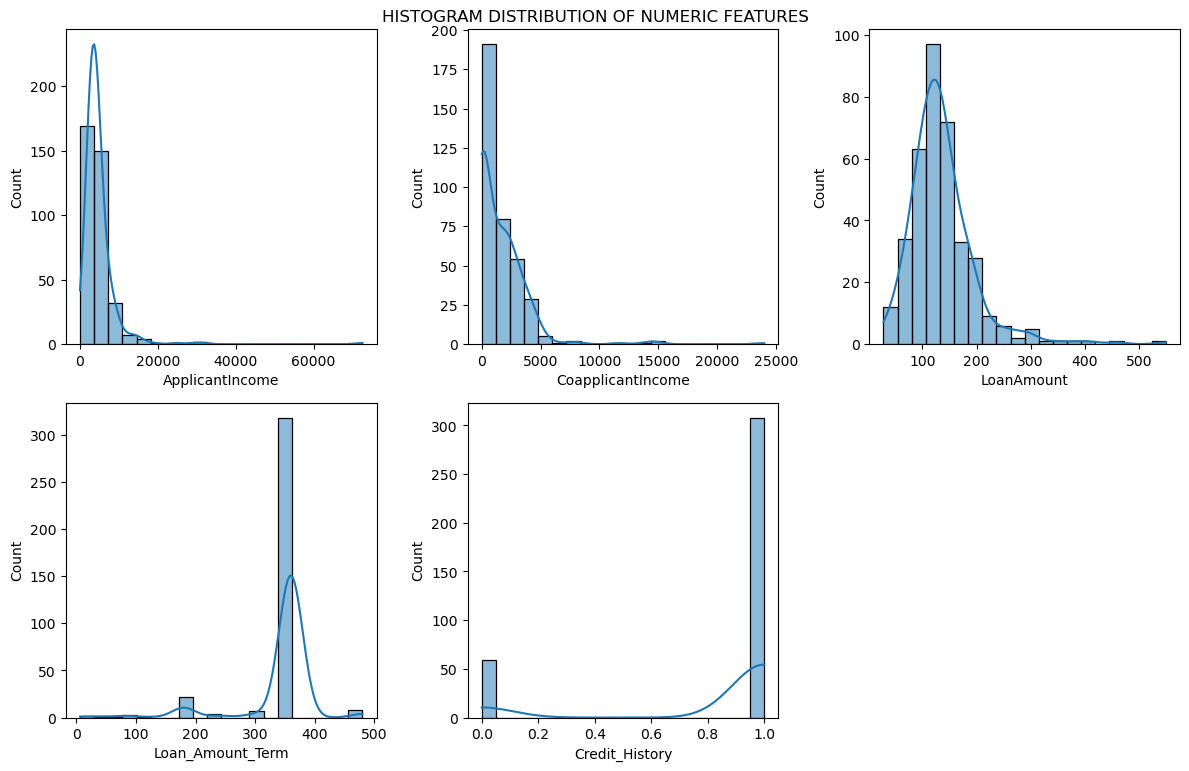

In [60]:

plt.figure(figsize=(12,15),facecolor="white")
plotnumber = 1
for i in df_1:
  plt.subplot(4,3,plotnumber)
  sns.histplot(df[i],kde=True,bins=20)
  plt.xlabel(i,fontsize=10)
  plt.ylabel("Count")
  plotnumber += 1
plt.suptitle("HISTOGRAM DISTRIBUTION OF NUMERIC FEATURES")
plt.tight_layout()
plt.show()

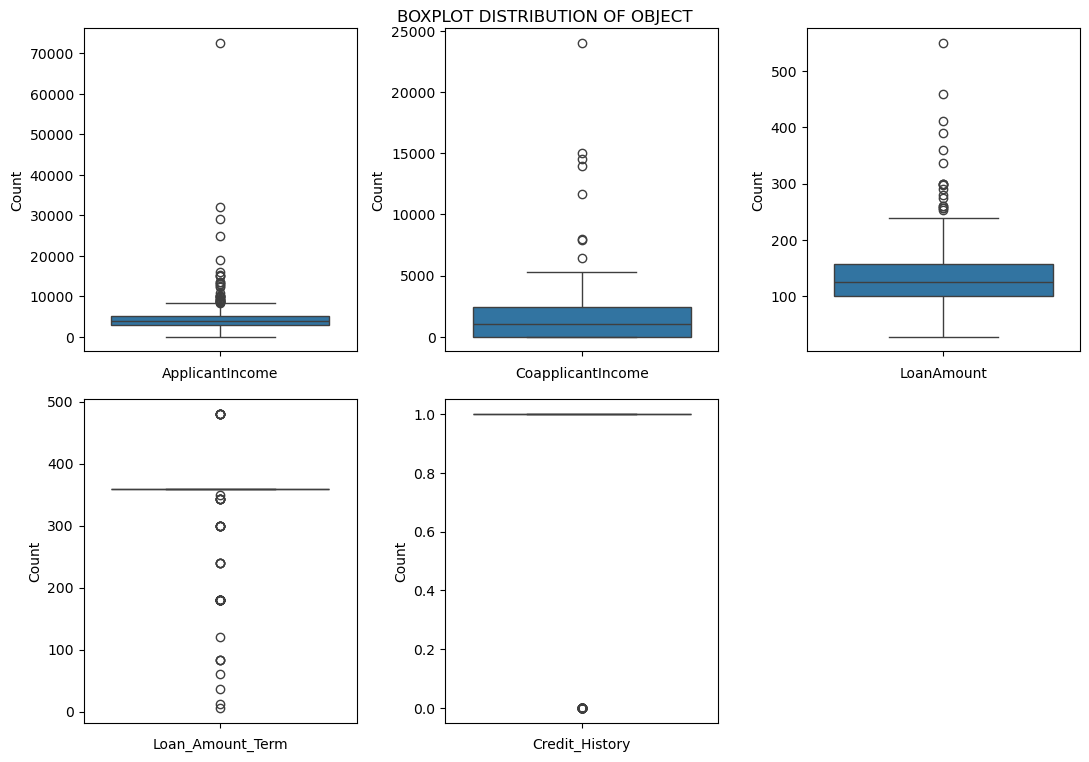

In [61]:

plt.figure(figsize=(11,15),facecolor="white")
plotnumber = 1
for i in df_1:
  plt.subplot(4,3,plotnumber)
  sns.boxplot(df[i])
  plt.xlabel(i,fontsize=10)
  plt.ylabel("Count")
  plotnumber += 1
plt.suptitle("BOXPLOT DISTRIBUTION OF OBJECT")
plt.tight_layout()
plt.show()

In [62]:
df_2 = df.select_dtypes(include="object")

In [63]:
df_2

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,Urban
1,LP001022,Male,Yes,1,Graduate,No,Urban
2,LP001031,Male,Yes,2,Graduate,No,Urban
3,LP001035,Male,Yes,2,Graduate,No,Urban
4,LP001051,Male,No,0,Not Graduate,No,Urban
...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,Urban
363,LP002975,Male,Yes,0,Graduate,No,Urban
364,LP002980,Male,No,0,Graduate,No,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,Rural


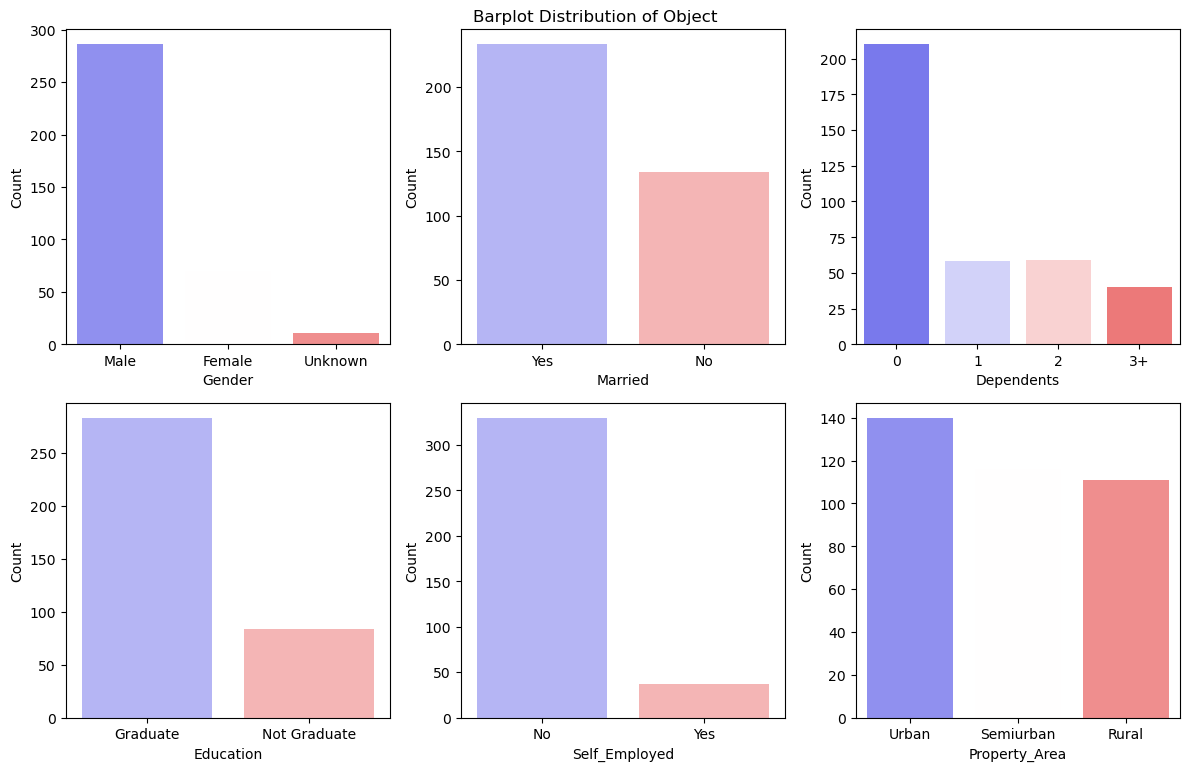

In [68]:

plt.figure(figsize=(12,15),facecolor="white")
plotnumber = 1
for i in df_2:
    plt.subplot(4,3,plotnumber)
    sns.countplot(x=df[i],palette='bwr')
    plt.xlabel(i,fontsize=10)
    plt.ylabel("Count")
    plotnumber += 1
plt.suptitle("Barplot Distribution of Object")
plt.tight_layout()
plt.show()

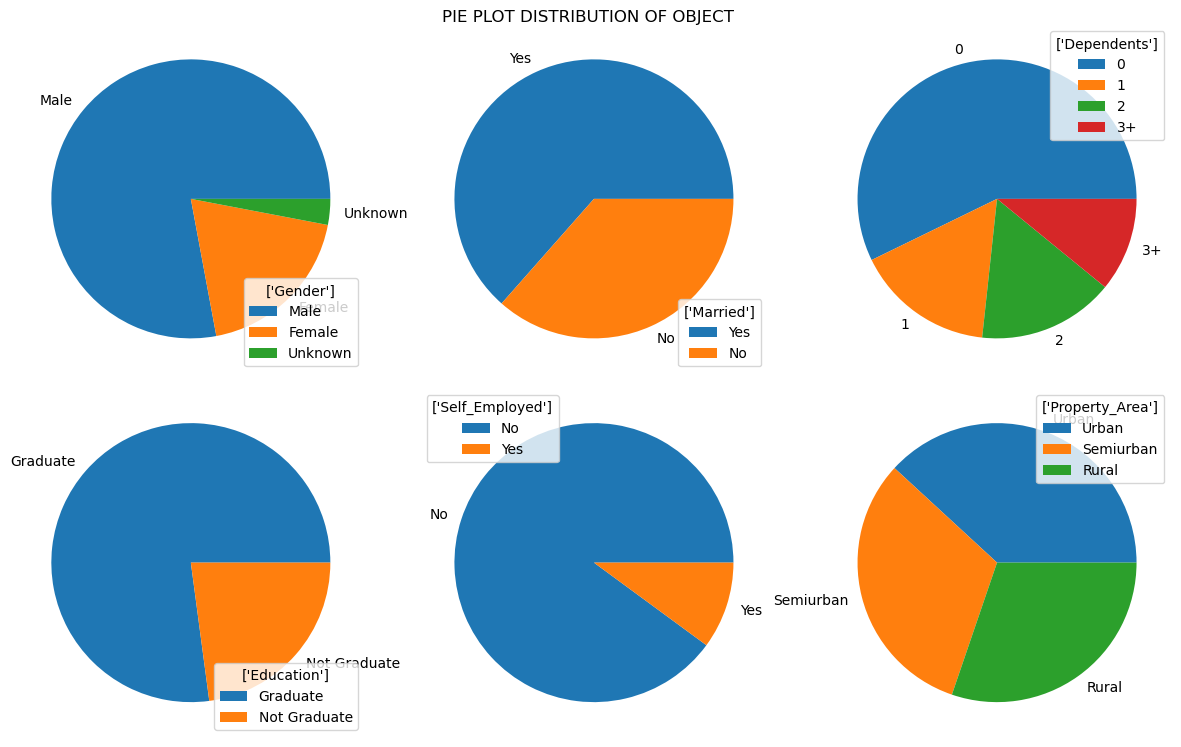

In [70]:

plt.figure(figsize=(12,15),facecolor="white")
plotnumber = 1
for i in df_2:
  plt.subplot(4,3,plotnumber)
  plt.pie(df[i].value_counts(),labels=df[i].unique())
  plt.legend(title=[i])
  plotnumber +=1
plt.suptitle("PIE PLOT DISTRIBUTION OF OBJECT")
plt.tight_layout()
plt.show()

- Bivariate Analysis -- Relationships --> Barcharts, Scatterplots, Swarm plots, Stripplots, boxplot

In [71]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


<Axes: xlabel='ApplicantIncome', ylabel='CoapplicantIncome'>

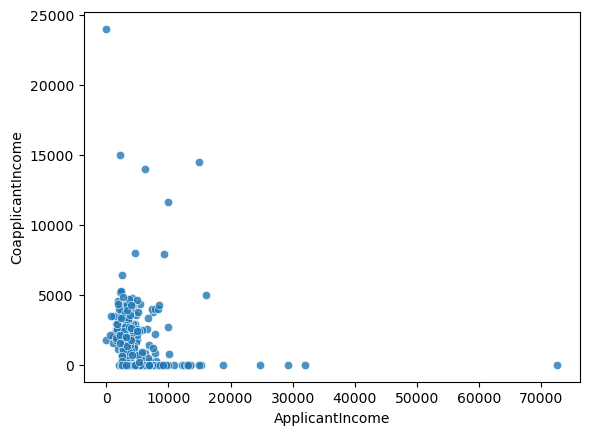

In [73]:
sns.scatterplot(data = df , x ="ApplicantIncome", y = "CoapplicantIncome", alpha=0.8)

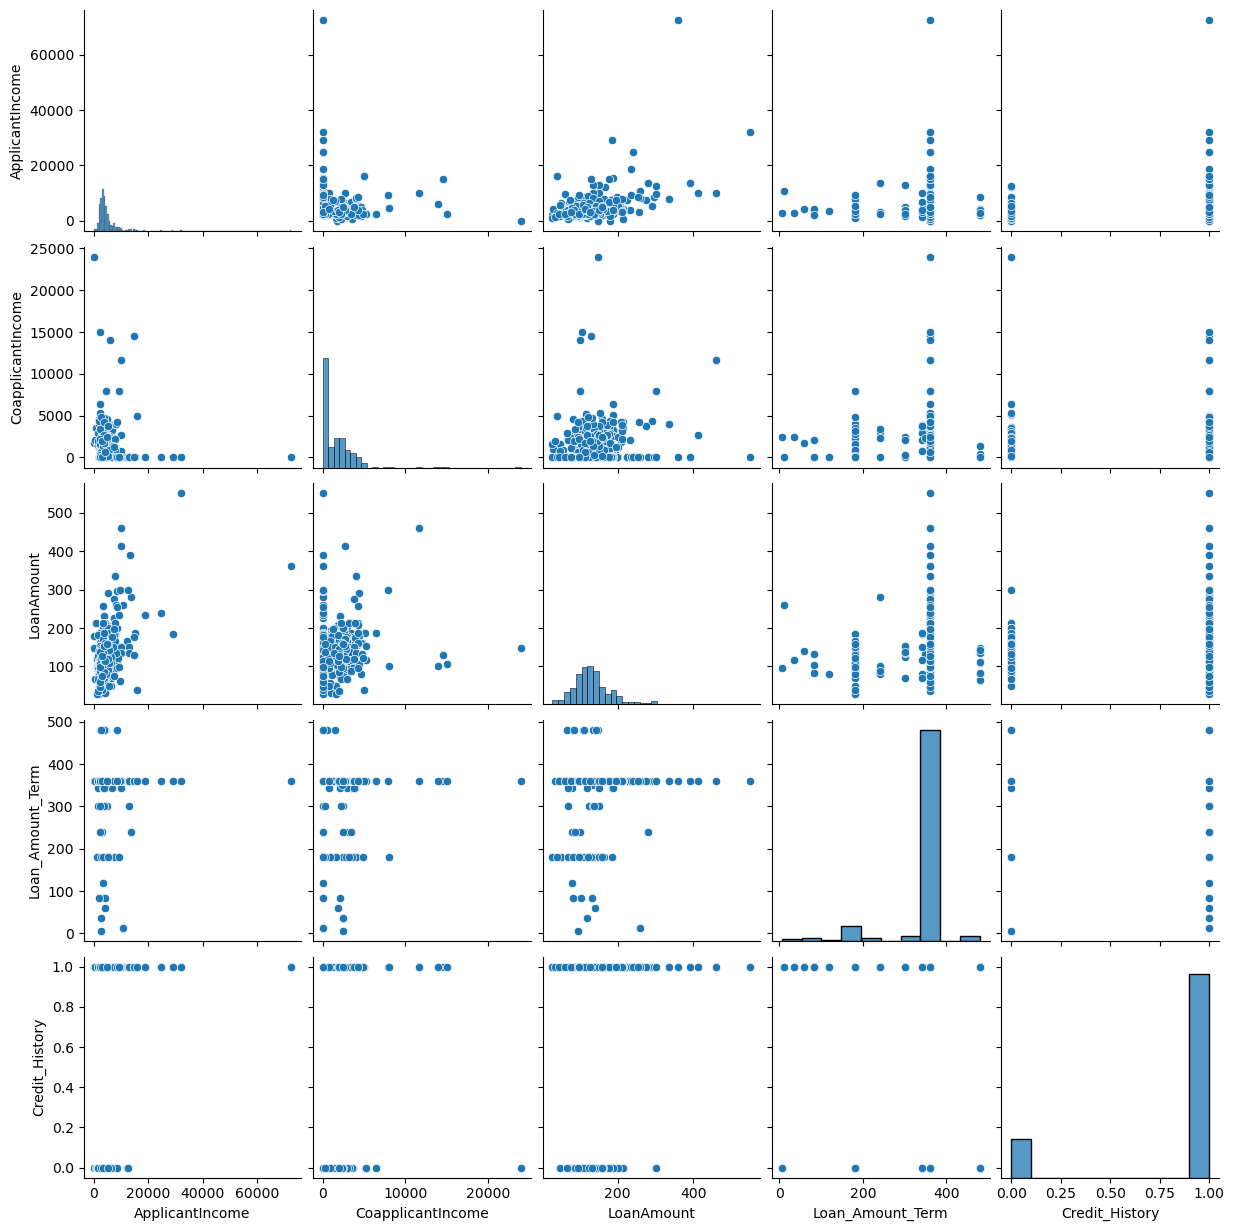

In [76]:
df_1=df.select_dtypes(include=["int64","float64"])
sns.pairplot(df_1)

- Investigate the relationship between
categorical and numeric variables using box
plots or violin plots.

<Axes: xlabel='Education', ylabel='LoanAmount'>

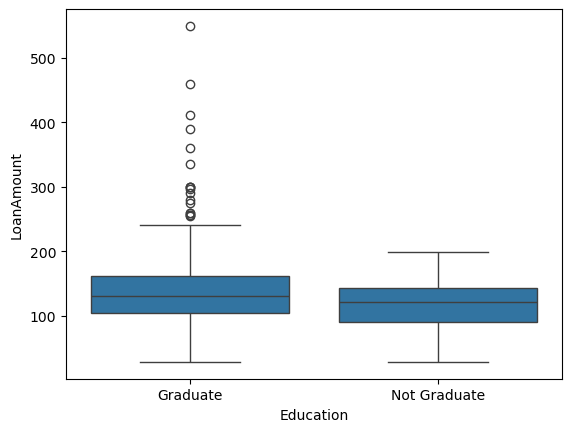

In [77]:
sns.boxplot(data = df , x="Education", y = "LoanAmount")

<Axes: xlabel='Property_Area', ylabel='Loan_Amount_Term'>

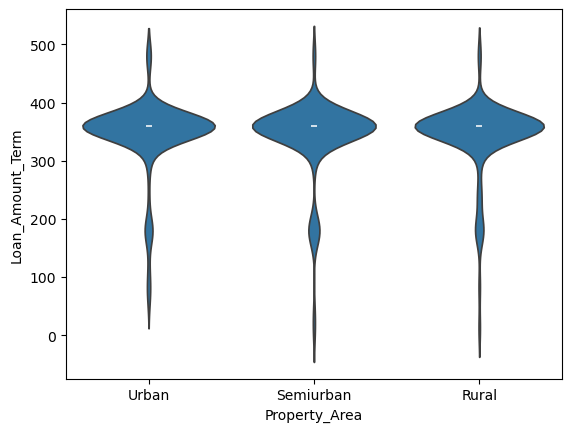

In [78]:
sns.violinplot(data = df , x = "Property_Area", y ="Loan_Amount_Term")

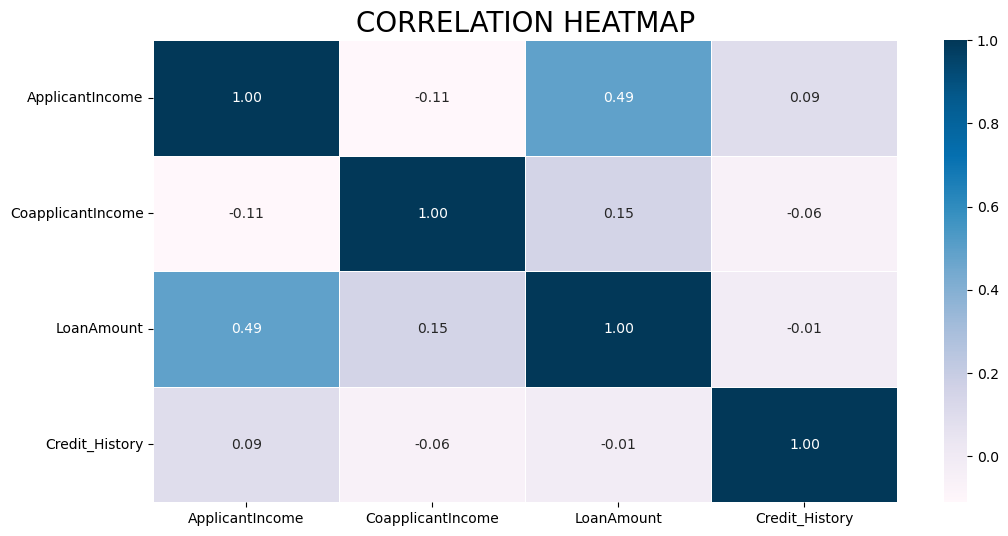

In [80]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount','Credit_History']
corr = df[num_cols].corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap='PuBu', fmt='.2f', linewidths=0.5)
plt.title('CORRELATION HEATMAP',fontsize=20)
plt.show()

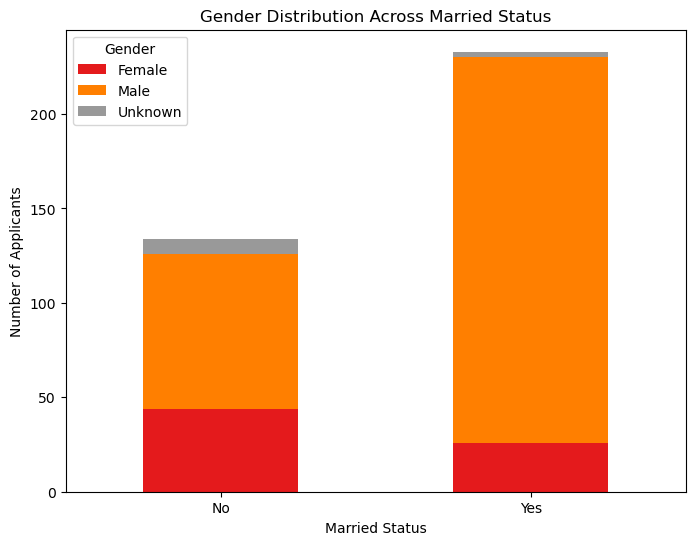

In [86]:
qct = pd.crosstab(df['Married'], df['Gender'])

qct.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Set1')

plt.title('Gender Distribution Across Married Status')
plt.xlabel('Married Status')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.show()

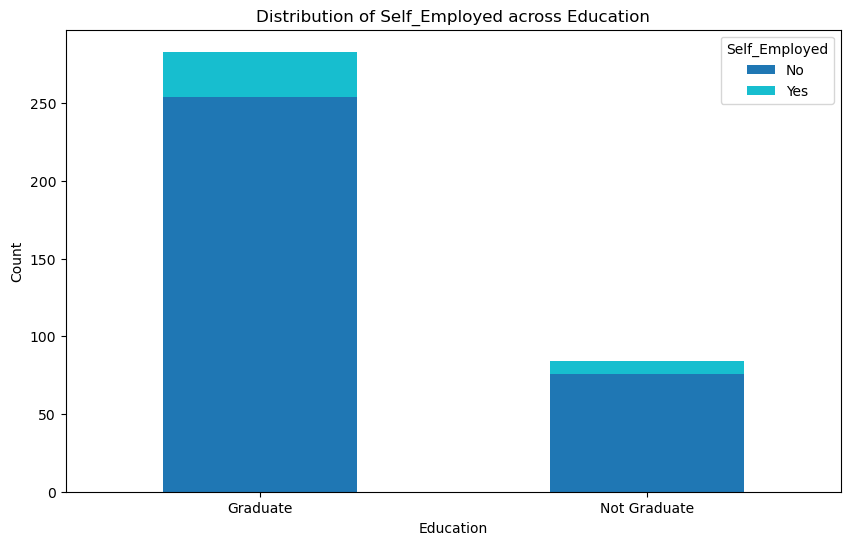

In [87]:
pd.crosstab(df['Education'], df['Self_Employed']).plot(
    kind='bar', stacked=True, figsize=(10,6), colormap='tab10'
)
plt.title('Distribution of Self_Employed across Education')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Self_Employed')
plt.show()

- The Stacked bar shows that Most graduate applicants are working professional jobs where in Not graduate applicants have less Self-employed and less job professionals

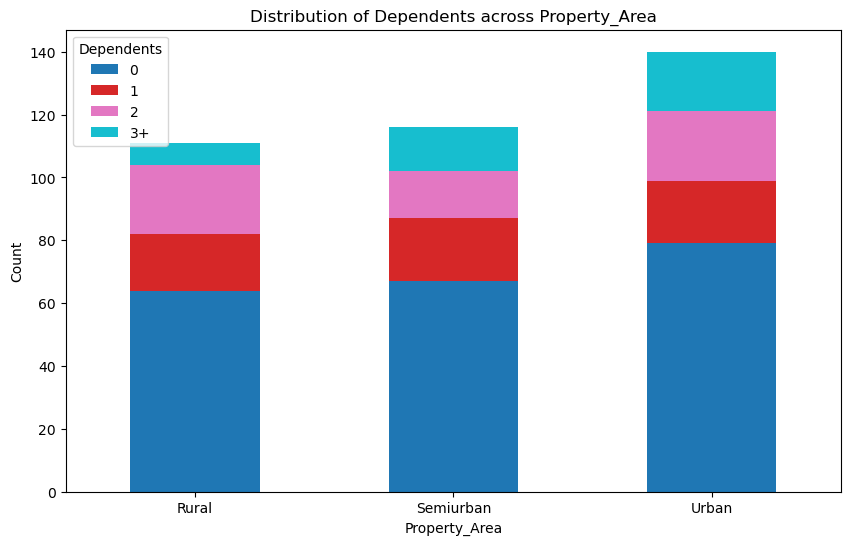

In [88]:
pd.crosstab(df['Property_Area'], df['Dependents']).plot(
    kind='bar', stacked=True, figsize=(10,6), colormap='tab10'
)
plt.title('Distribution of Dependents across Property_Area')
plt.xlabel('Property_Area')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Dependents')
plt.show()

- The stacked bar chart showing the distribution of Dependents across Property_Area reveals that applicants from semiurban areas make up the largest group across most dependent categories. Applicants with zero dependents dominate in all property areas, especially in urban and semiurban regions. Rural areas show a slightly higher proportion of applicants with one or more dependents, suggesting family size may vary with geographic location. This insight can assist in tailoring financial products and support services according to regional demographic characteristics.